# Hospital Readmission Prediction
### Logistic Regression Case Study

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_auc_score, RocCurveDisplay
)

## 1. Load Data

In [2]:
df = pd.read_csv('/content/hospital_readmissions_30k.csv.xls')
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


## 2. Class Distribution
Check for imbalance before anything else — medical datasets are almost always skewed.

Target distribution (counts):
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64

Target distribution (proportions):
readmitted_30_days
No     0.878
Yes    0.122
Name: proportion, dtype: float64


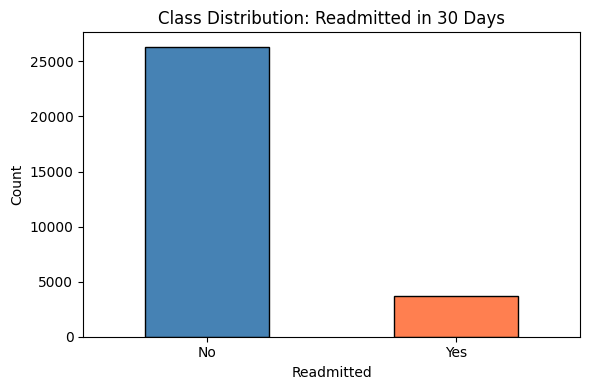

In [4]:
print("Target distribution (counts):")
print(df['readmitted_30_days'].value_counts())
print()
print("Target distribution (proportions):")
print(df['readmitted_30_days'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
df['readmitted_30_days'].value_counts().plot(
    kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black'
)
ax.set_title('Class Distribution: Readmitted in 30 Days')
ax.set_xlabel('Readmitted')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

## 3. Null Value Check & Imputation
Checking AND handling — not just printing.

In [5]:
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


In [6]:
# Impute: median for numeric, mode for categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Null values after imputation:")
print(df.isnull().sum())

Null values after imputation:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


## 4. Feature Engineering

In [7]:
# Split blood_pressure into two numeric columns
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split('/', expand=True)
df['systolic_bp'] = pd.to_numeric(df['systolic_bp'])
df['diastolic_bp'] = pd.to_numeric(df['diastolic_bp'])
df.drop('blood_pressure', axis=1, inplace=True)

# Drop patient_id — not a feature
df.drop('patient_id', axis=1, inplace=True)

df.head()

,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp
0,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130,72
1,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120,92
2,89,Other,153,30.3,No,Yes,1,1,Home,No,135,78
3,84,Female,153,31.5,No,Yes,3,10,Home,No,123,80
4,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135,84


## 5. Encoding

In [8]:
# Binary label encoding
df['diabetes'] = df['diabetes'].map({'Yes': 1, 'No': 0})
df['hypertension'] = df['hypertension'].map({'Yes': 1, 'No': 0})
df['readmitted_30_days'] = df['readmitted_30_days'].map({'Yes': 1, 'No': 0})

# One-hot encode multi-class categoricals
df = pd.get_dummies(df, columns=['gender', 'discharge_destination'], drop_first=True)

# Cast bool columns to int (pandas >= 1.3 returns bool for get_dummies)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,systolic_bp,diastolic_bp,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab
0,74,240,31.5,1,0,5,1,1,130,72,0,1,1,0
1,46,292,36.3,0,0,4,3,0,120,92,0,0,1,0
2,89,153,30.3,0,1,1,1,0,135,78,0,1,0,0
3,84,153,31.5,0,1,3,10,0,123,80,0,0,0,0
4,32,205,18.4,0,1,6,4,0,135,84,0,1,1,0


## 6. Train / Test Split
X/y split happens here — after all preprocessing, not before.

In [9]:
X = df.drop('readmitted_30_days', axis=1)
y = df['readmitted_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y  # stratify preserves class ratio
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 21000 | Test size: 9000


## 7. Feature Scaling

In [10]:
scaler = StandardScaler()

# fit_transform on train only — prevents data leakage into test set
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 8. Model Training
-  — default 100 will not converge on 30k rows  
-  — compensates for class imbalance automatically

In [11]:
logmodel = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=1)
logmodel.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 9. Predictions

In [12]:
predictions = logmodel.predict(X_test)
pred_proba = logmodel.predict_proba(X_test)[:, 1]  # probability of class 1

## 10. Evaluation

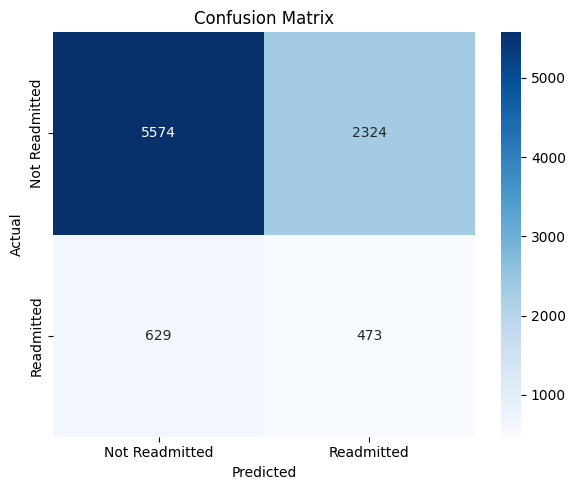

In [13]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, predictions)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Not Readmitted', 'Readmitted'],
    yticklabels=['Not Readmitted', 'Readmitted']
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [14]:
print(classification_report(
    y_test, predictions,
    target_names=['Not Readmitted', 'Readmitted']
))

                precision    recall  f1-score   support

Not Readmitted       0.90      0.71      0.79      7898
    Readmitted       0.17      0.43      0.24      1102

      accuracy                           0.67      9000
     macro avg       0.53      0.57      0.52      9000
  weighted avg       0.81      0.67      0.72      9000



In [15]:
accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print()
print("Note: For imbalanced medical data, ROC-AUC is the primary metric.")

Accuracy : 0.6719
ROC-AUC  : 0.5714

Note: For imbalanced medical data, ROC-AUC is the primary metric.


## 11. ROC Curve

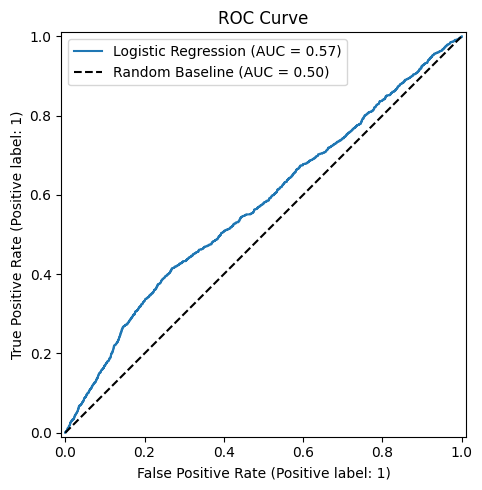

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, pred_proba, ax=ax, name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.50)')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Feature Importance (Coefficients)
Positive coefficients increase readmission probability; negative coefficients decrease it.

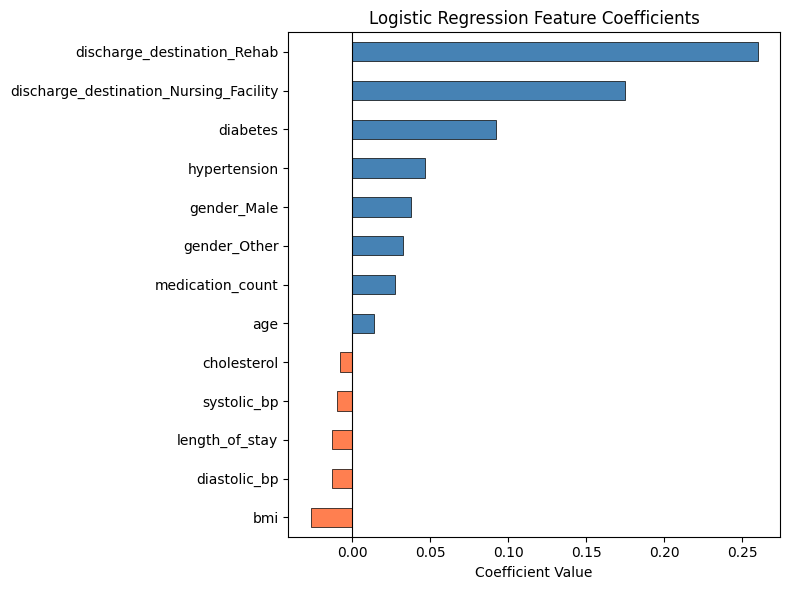

In [17]:
feature_names = df.drop('readmitted_30_days', axis=1).columns
coef_series = pd.Series(logmodel.coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if c < 0 else 'steelblue' for c in coef_series]
coef_series.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()